# Project Overview & Dataset

## Problem Statement
The objective of this project is to develop a machine learning model capable of automatically categorizing IT support tickets.

## Dataset Description
This project uses the IT Support Ticket Data dataset.

# Project Setup

In [50]:
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import re

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# stopwords removal imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## Download dataset

In [51]:
# Download latest version

DATA_FOLDER = "../data"

FILE_NAME = "IT Support Ticket Data.csv"

path = kagglehub.dataset_download("parthpatil256/it-support-ticket-data")

print("Dataset downloaded to cache:", path)

if not os.path.exists(DATA_FOLDER):
    os.mkdir(DATA_FOLDER)
    print(f"Folder created: {DATA_FOLDER}")

src_path = os.path.join(path, FILE_NAME)
dest_path = os.path.join(DATA_FOLDER, FILE_NAME)

if not os.path.exists(dest_path):
    if os.path.exists(src_path):
        print(f"Copying '{FILE_NAME}' to the project folder...")
        shutil.copy(src_path, dest_path)
        print("Copy finished successfully.")
    else:
        print(f"File '{FILE_NAME}' not found in the downloaded files.")
else:
    print(f"File '{FILE_NAME}' already exists in {DATA_FOLDER}. Skipping copy.")

# Verification
print(f"Files in {DATA_FOLDER}: {os.listdir(DATA_FOLDER)}")

Dataset downloaded to cache: /home/jano/.cache/kagglehub/datasets/parthpatil256/it-support-ticket-data/versions/1
File 'IT Support Ticket Data.csv' already exists in ../data. Skipping copy.
Files in ../data: ['IT Support Ticket Data.csv']


# Load and Exploratory Data Analysis

## Basic Dataset Inspection

In [52]:
df_original = pd.read_csv(dest_path, index_col=0)

# basic info
print("Dataset info:")
print(df_original.info())
print("#"*50)
print("\nFirst 5 rows:")
display(df_original.head(5))
print("\nDataset shape:")
print(df_original.shape)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB
None
##################################################

First 5 rows:


,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."



Dataset shape:
(29651, 4)


## Distribution of Objective Variables

In [53]:
print("--- Department distribution in percentage ---")
display((df_original["Department"].value_counts(normalize=True)*100).round(2))

print("\n--- Priority distribution in percentage ---")
display((df_original["Priority"].value_counts(normalize=True)*100).round(2))

--- Department distribution in percentage ---


Department
Technical Support                  29.06
Product Support                    18.68
Customer Service                   15.12
IT Support                         11.80
Billing and Payments               10.18
Returns and Exchanges               4.95
Service Outages and Maintenance     3.90
Sales and Pre-Sales                 2.98
Human Resources                     1.92
General Inquiry                     1.41
Name: proportion, dtype: float64


--- Priority distribution in percentage ---


Priority
medium    40.90
high      38.82
low       20.28
Name: proportion, dtype: float64

## Missing Data Detection

Text representation:

Department    0
Priority      0
Tags          0
Body          1
dtype: int64

Graphic representation


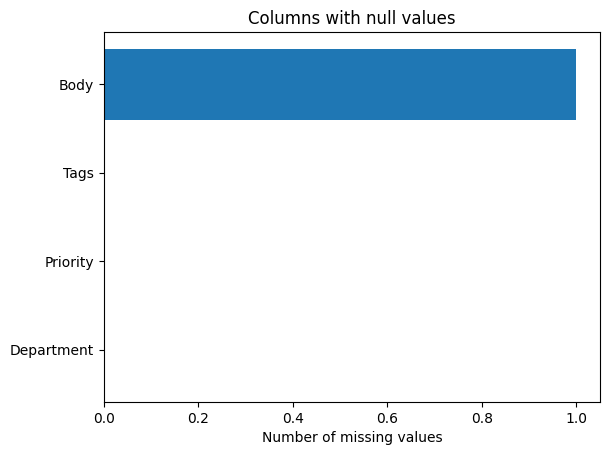

In [54]:
null_sum = df_original.isnull().sum()
null_sum = null_sum.sort_values(ascending=True)
print("Text representation:\n")
print(null_sum)

print("\nGraphic representation")
plt.barh(null_sum.index,null_sum.values)
plt.title("Columns with null values")
plt.xlabel('Number of missing values')
plt.show()

## Objective Variable Distribution

### Department Distribution

Text representation:

Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64

Graphic representation


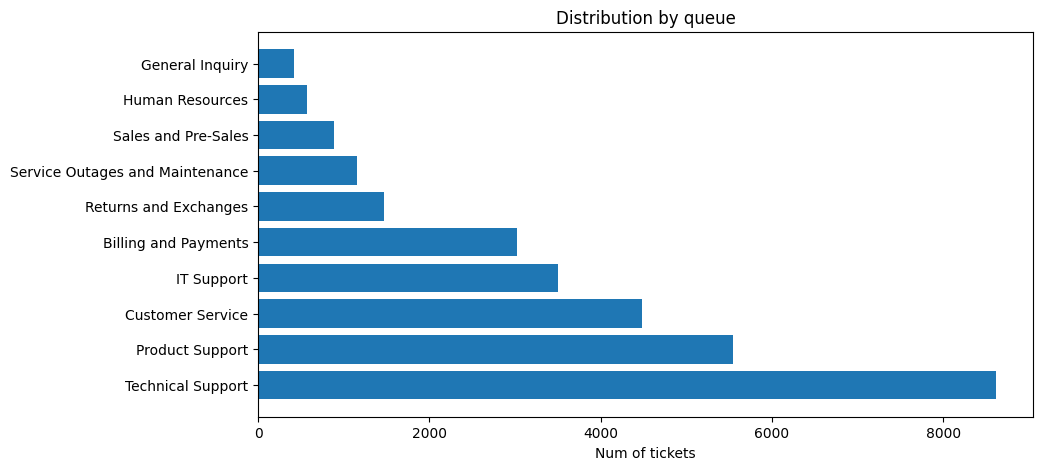

In [55]:
department_tickets = df_original["Department"].value_counts()
print("Text representation:\n")
print(department_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(department_tickets.index,department_tickets.values)
ax.set_title("Distribution by queue")
ax.set_xlabel("Num of tickets")
plt.show()

### Priority Distribution

Text representation:

Priority
medium    12126
high      11512
low        6013
Name: count, dtype: int64

Graphic representation


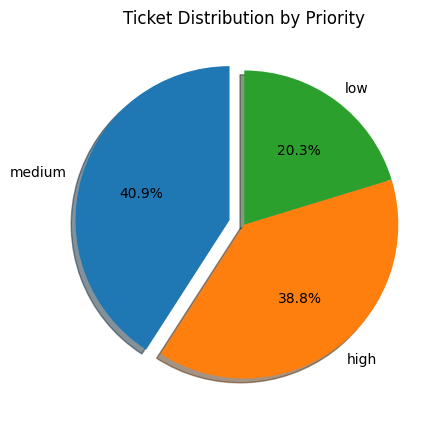

In [56]:
priority_tickets = df_original["Priority"].value_counts()
print("Text representation:\n")
print(priority_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
explode = (0.1, 0, 0)
ax.pie(priority_tickets.values, labels=priority_tickets.index, explode=explode,
        shadow=True, autopct='%1.1f%%', startangle=90)

plt.title("Ticket Distribution by Priority")
plt.show()

## Text Length

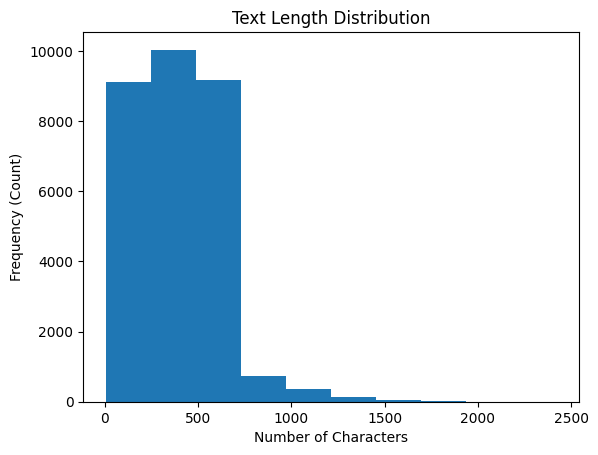

In [57]:
fig, ax = plt.subplots()
ax.hist(df_original["Body"].str.len())
ax.set_title("Text Length Distribution")
ax.set_xlabel("Number of Characters")
ax.set_ylabel("Frequency (Count)")
plt.show()

# Data Preprocessing

In [58]:
# create a copy from the original df to mantain the original dataset untouch
df = df_original.copy()

display(df.info())

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB


None

,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


## Drop Null Values

In [59]:
# Drop null values from body
df = df.dropna(subset=["Body"])
df = df.reset_index(drop=True)

top_departments = ["Technical Support", "Product Support", "Customer Service", "IT Support"]

df = df[df["Department"].isin(top_departments)]
df = df.reset_index(drop=True)

df.info()

print("\n--- Distribution after get only top 4 departments ---")
print(df["Department"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 22137 entries, 0 to 22136
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        22137 non-null  str  
 1   Department  22137 non-null  str  
 2   Priority    22137 non-null  str  
 3   Tags        22137 non-null  str  
dtypes: str(4)
memory usage: 691.9 KB

--- Distribution after get only top 4 departments ---
Department
Technical Support    8617
Product Support      5538
Customer Service     4482
IT Support           3500
Name: count, dtype: int64


## Clean Text

In [60]:
# download stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/jano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [61]:
# Select a random ticket to see if it has strange characters
rng = np.random.default_rng()

rand_num = rng.integers(0, len(df))

df["Body"].iloc[rand_num]

'I would like to explore the possibility of integrating Kaspersky security features with the Joystick project management tool to better protect our project data and maintain a secure working environment. Could you provide information on whether this integration is feasible and what steps are required to implement it? I am looking forward to your response and assistance.'

In [62]:
# Clean literal escape sequences (e.g., \n, \r) and remove extra whitespaces
def clean_text(text):
    text = text.lower()

    # remove sequence escape literals (e.g: \n, \r, \t,...)
    text = re.sub(r'\\[nrt]', ' ', text)

    # remove html tags (e.g: <br>,...)
    text = re.sub(r'<[^>]+>', ' ', text)

    # remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # stopword removal
    tokens = word_tokenize(text)

    text = " ".join([word for word in tokens if word not in stop_words])

    return text

df["clean_body"] = df["Body"].apply(clean_text)

df["clean_body"].iloc[rand_num]

'would like explore possibility integrating kaspersky security features joystick project management tool better protect project data maintain secure working environment . could provide information whether integration feasible steps required implement ? looking forward response assistance .'

## Target Variable Encoding

In [63]:
# Target Variable Encoding
le = LabelEncoder()

df["encoded_department"] = le.fit_transform(df["Department"])

print(le.classes_)

['Customer Service' 'IT Support' 'Product Support' 'Technical Support']


## Split Dataset

In [64]:
# split dataset on train and test
X = df['clean_body']

y = df['encoded_department']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print('-> Train shape:')
print(X_train.shape)
print(y_train.shape)

print('\n-> Test shape:')
print(X_test.shape)
print(y_test.shape)

-> Train shape:
(17709,)
(17709,)

-> Test shape:
(4428,)
(4428,)


# Model Training & Evaluation

## Baseline Model

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

tfidf = TfidfVectorizer(max_features=20000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

base_model = LinearSVC(max_iter=1000, random_state=42, class_weight="balanced")

base_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

### Evaluate Base model

                   precision    recall  f1-score   support

 Customer Service       0.53      0.54      0.53       896
       IT Support       0.48      0.54      0.51       700
  Product Support       0.54      0.52      0.53      1108
Technical Support       0.62      0.60      0.61      1724

         accuracy                           0.56      4428
        macro avg       0.54      0.55      0.54      4428
     weighted avg       0.56      0.56      0.56      4428



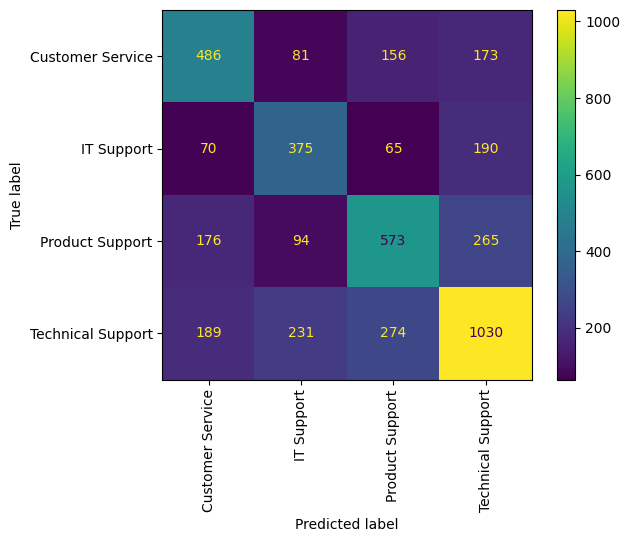

In [66]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = base_model.predict(X_test_tfidf)

print(classification_report(y_test,y_pred, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=le.classes_, xticks_rotation='vertical')
plt.show()

## DeepLearning Model

In [67]:
from keras.layers import TextVectorization

max_tokens = 10000
max_length = 500

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,              # Vocabulary limit
    output_mode='int',                  # generate the output in ints
    output_sequence_length=max_length   # sequence output length
)

vectorize_layer.adapt(df["clean_body"])

print("Vocabulary:\n============")

for index, token in enumerate(vectorize_layer.get_vocabulary()[:20]):
    print(f"{index:3d}: '{token}'")

Vocabulary:
  0: ''
  1: '[UNK]'
  2: 'data'
  3: 'issue'
  4: 'would'
  5: 'support'
  6: 'could'
  7: 'assistance'
  8: 'customer'
  9: 'software'
 10: 'provide'
 11: 'appreciate'
 12: 'please'
 13: 'information'
 14: 'due'
 15: 'problem'
 16: 'security'
 17: 'might'
 18: 'greatly'
 19: 'analytics'


In [76]:
import numpy as np
from keras import layers
from keras.models import Sequential

embedding_dim = 64 

model = Sequential([
    vectorize_layer,  # convert text to int sequences
    layers.Embedding(input_dim=max_tokens, output_dim=embedding_dim, mask_zero=True),
    layers.Bidirectional(layers.LSTM(embedding_dim)),
    layers.Dropout(0.5),
    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [77]:
import tensorflow as tf
from keras.callbacks import EarlyStopping
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

X = tf.constant(X_train, dtype=tf.string)

callbacks = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    X, y_train,
    epochs=50, validation_split=0.2,
    callbacks=callbacks,verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.3497 - loss: 1.3145 - val_accuracy: 0.3594 - val_loss: 1.2769
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4993 - loss: 1.1155 - val_accuracy: 0.4489 - val_loss: 1.2201
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.6188 - loss: 0.9023 - val_accuracy: 0.5426 - val_loss: 1.0978
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7030 - loss: 0.7240 - val_accuracy: 0.5339 - val_loss: 1.1926
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7735 - loss: 0.5714 - val_accuracy: 0.5723 - val_loss: 1.1865
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8214 - loss: 0.4483 - val_accuracy: 0.5822 - val_loss: 1.2529


In [78]:
X_test_tf = tf.constant(X_test, dtype=tf.string)

loss, accuracy = model.evaluate(X_test_tf, y_test, verbose=0)

print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Test Loss: 1.0825
Test Accuracy: 0.5427


139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


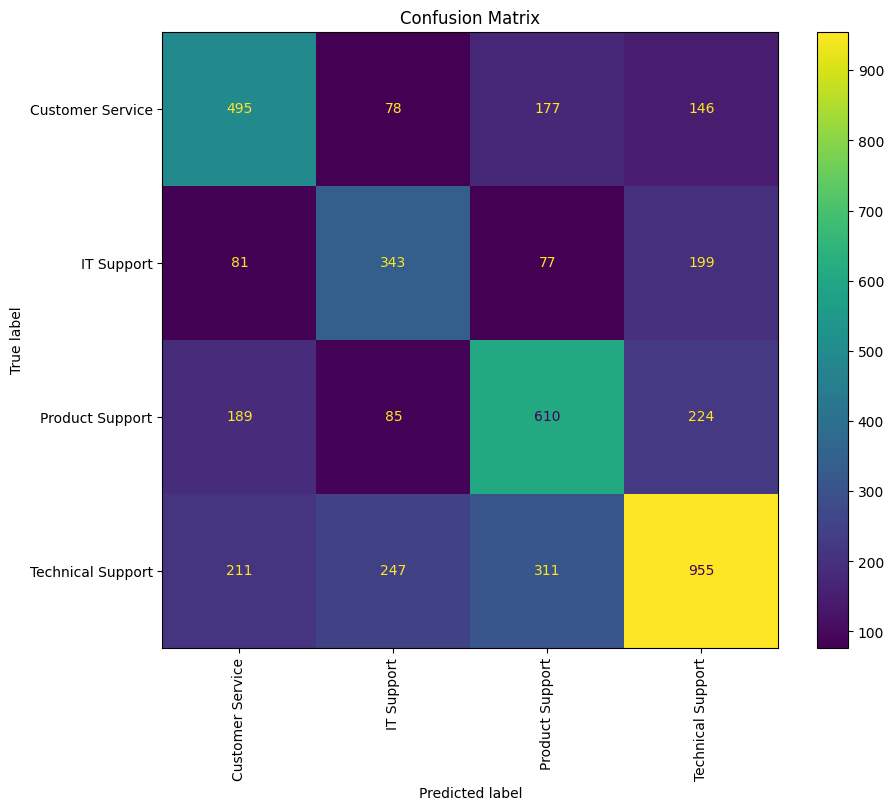

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on the test set
X_test_tf = tf.constant(X_test, dtype=tf.string)
predictions = model.predict(X_test_tf)
predicted_classes = np.argmax(predictions, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
display_cm.plot(ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()